# Create a 2D mask with zero in the Lab Sea and one elsewhere

In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import datetime
import subprocess, os, warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [7]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [5]:
grd = xr.open_dataset('../mesh/tx2_3v3_grid.nc')
grd

<xarray.Dataset>
Dimensions:  (ny: 480, nx: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: ny, nx, nxp, nyp
Data variables: (12/20)
    tlon     (ny, nx) float64 ...
    tlat     (ny, nx) float64 ...
    ulon     (ny, nxp) float64 ...
    ulat     (ny, nxp) float64 ...
    vlon     (nyp, nx) float64 ...
    vlat     (nyp, nx) float64 ...
    ...       ...
    tarea    (ny, nx) float64 ...
    tmask    (ny, nx) float64 ...
    angle    (ny, nx) float64 ...
    depth    (ny, nx) float64 ...
    ar       (ny, nx) float64 ...
    egs      (ny, nx) float64 ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [8]:
masks = xr.open_dataset('/glade/work/gmarques/cesm/tx2_3/basin_masks/basin_masks_tx2_3v3_260306.nc')
masks = masks.rename({'yh':'LAT', 'xh':'LON'})

In [11]:
masks

<xarray.Dataset>
Dimensions:      (region: 18, LAT: 480, LON: 540)
Coordinates:
  * region       (region) <U17 'Global' 'PersianGulf' ... 'SouthernOcean60S'
Dimensions without coordinates: LAT, LON
Data variables:
    basin_masks  (region, LAT, LON) float64 ...

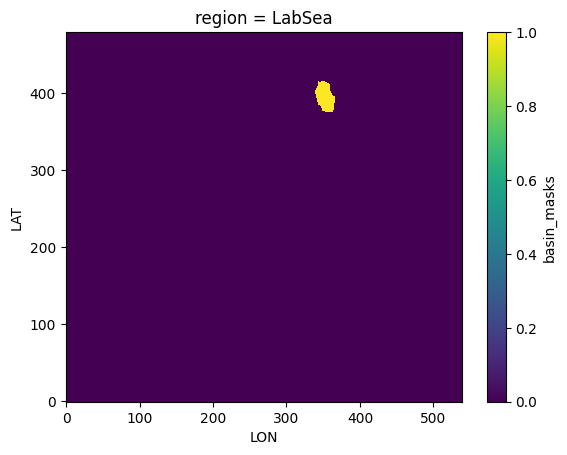

In [9]:
masks.basin_masks.sel(region='LabSea').plot()

In [13]:
#create dataset

# extract coordinates from masks dataset
lat = masks["LAT"]
lon = masks["LON"]
fill = -1e34
# create empty Cr field
Cr = xr.DataArray(
    np.full((lat.size, lon.size), fill, dtype="float32"),
    dims=("LAT", "LON"),
    coords={"LAT": lat, "LON": lon},
    name="Cr"
)

# add attributes
Cr.attrs = {
    "_FillValue": fill,
    "long_name": "mask, 0 in the Lab Sea 1 elsewhere",
    "units": "nondim",
    "missing_value": fill
}

# ensure coordinate attributes exist
lat.attrs.update({"units": "degrees_north", "axis": "Y"})
lon.attrs.update({"units": "degrees_east", "axis": "X"})

# create dataset
ds = xr.Dataset(
    {"Cr": Cr},
    coords={"LAT": lat, "LON": lon}
)

print(ds)

<xarray.Dataset>
Dimensions:  (LAT: 480, LON: 540)
Coordinates:
  * LAT      (LAT) int64 0 1 2 3 4 5 6 7 8 ... 472 473 474 475 476 477 478 479
  * LON      (LON) int64 0 1 2 3 4 5 6 7 8 ... 532 533 534 535 536 537 538 539
Data variables:
    Cr       (LAT, LON) float32 -1e+34 -1e+34 -1e+34 ... -1e+34 -1e+34 -1e+34


In [14]:
lats_out = np.zeros(len(ds.LAT))
for j in range(len(ds.LAT)):
    if grd.tlat[j,0] <= 0.:
      lats_out[j] = np.min(grd.tlat[j,0:])
    else:
      lats_out[j] = np.max(grd.tlat[j,0:])

In [15]:
ds = ds.assign_coords({
    "LAT": (("LAT"), lats_out),
    "LON": (("LON"), grd.tlon[0,:].data)
  })

In [17]:
ds['Cr'][:] = 1.0 

In [18]:
ds['Cr'][:] = ds['Cr'][:].where(masks.basin_masks.sel(region='LabSea') != 1, 0)

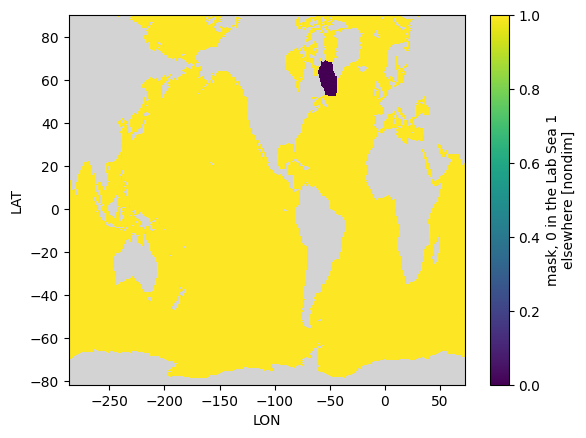

In [19]:
cmap = plt.cm.viridis.copy()  # or any other colormap, e.g., 'RdBu_r'
cmap.set_bad(color='lightgray') 

fig, ax = plt.subplots()

(ds['Cr']).where(grd.tmask.rename({'nx' : 'LON','ny' : 'LAT'})==1).plot(ax=ax, cmap=cmap, vmax=1)

In [13]:
# Global attrs
ds.attrs['long_name'] = 'MLE Cr mask (0 in the Lab Sea and 1 elsewhere)'
ds.attrs['units'] = 'nondim'
ds.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
ds.attrs['date'] = datetime.now().isoformat()
ds.attrs['url'] = 'https://github.com/NCAR/tx2_3/mle_frontal_length_scale/'

ds['LON'].encoding['_FillValue']=None
ds['LAT'].encoding['_FillValue']=None
ds['LAT'].attrs['units'] = 'degrees_north'
ds['LAT'].attrs['axis'] = 'Y'

ds['LON'].attrs['units'] = 'degrees_east'
ds['LON'].attrs['axis'] = 'X'

In [22]:
fname = 'mle_cr_labsea_mask_tx2_3v3_{}.nc'.format(today)
# Save file
ds.to_netcdf(fname, engine="netcdf4", format="NETCDF3_64BIT_DATA")

# Close the dataset
ds.close()